U prethodnim eksperimentima primijećeno je da SVM model postiže izuzetno visoku tačnost, posebno nad originalnim (raw) i PCA40 podacima, gdje tačnost dostiže 1.0.

SVM Raw Accuracy: 1.0000
SVM PCA20 Accuracy: 0.9938
SVM PCA40 Accuracy: 1.0000

Ovakvi rezultati mogu ukazivati na preprilagođavanje (overfitting), gdje model previše dobro pamti trening podatke i potencijalno loše generalizuje na nove podatke.

Kako bi se ovaj problem ispitao, koristi se cross-validation, koja omogućava realniju procjenu performansi modela.

In [59]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
raw_path = "../data/raw"

df_raw = pd.read_csv(os.path.join(raw_path, "clean2.data"), header=None)

In [61]:
n_cols = df_raw.shape[1]
columns = ["ID"] + [f"attr_{i}" for i in range(1, n_cols)]
df_raw.columns = columns

print("RAW shape:", df_raw.shape)
df_raw.head()

RAW shape: (6598, 169)


,ID,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,attr_10,attr_11,attr_12,attr_13,attr_14,attr_15,attr_16,attr_17,attr_18,attr_19,attr_20,attr_21,attr_22,attr_23,attr_24,attr_25,attr_26,attr_27,attr_28,attr_29,attr_30,attr_31,attr_32,attr_33,attr_34,attr_35,attr_36,attr_37,attr_38,attr_39,attr_40,attr_41,attr_42,attr_43,attr_44,attr_45,attr_46,attr_47,attr_48,attr_49,attr_50,attr_51,attr_52,attr_53,attr_54,attr_55,attr_56,attr_57,attr_58,attr_59,...,attr_109,attr_110,attr_111,attr_112,attr_113,attr_114,attr_115,attr_116,attr_117,attr_118,attr_119,attr_120,attr_121,attr_122,attr_123,attr_124,attr_125,attr_126,attr_127,attr_128,attr_129,attr_130,attr_131,attr_132,attr_133,attr_134,attr_135,attr_136,attr_137,attr_138,attr_139,attr_140,attr_141,attr_142,attr_143,attr_144,attr_145,attr_146,attr_147,attr_148,attr_149,attr_150,attr_151,attr_152,attr_153,attr_154,attr_155,attr_156,attr_157,attr_158,attr_159,attr_160,attr_161,attr_162,attr_163,attr_164,attr_165,attr_166,attr_167,attr_168
0,MUSK-211,211_1+1,46,-108,-60,-69,-117,49,38,-161,-8,5,-323,-220,-113,-299,-283,-307,-31,-106,-227,-42,-59,-22,-67,189,81,17,-27,-89,-67,105,-116,124,-106,5,-120,63,-165,40,-27,68,-44,98,-33,-314,-282,-335,-144,-13,-197,-2,-144,-13,-11,-131,108,-43,42,-151,...,-35,-205,-280,-239,-53,-10,-23,25,-5,163,61,59,-39,92,72,113,-107,80,25,-27,81,-114,-187,45,-118,-75,-182,-234,-19,12,-13,-41,-119,-149,70,17,-20,-177,-101,-116,-14,-50,24,-81,-125,-114,-44,128,3,-244,-308,52,-7,39,126,156,-50,-112,96,1.0
1,MUSK-211,211_1+10,41,-188,-145,22,-117,-6,57,-171,-39,-100,-319,-111,-228,-281,-281,-300,54,-149,-98,-196,-27,-22,2,75,49,-34,45,-91,32,95,-116,85,-23,42,-58,61,-171,2,-144,38,-153,113,-166,-318,-241,-329,-97,-69,-108,-179,-71,-27,-12,-133,107,-96,92,-140,...,-117,-244,-246,-231,3,-2,-3,15,49,99,37,84,22,66,131,109,-77,-10,-17,17,88,-21,-32,32,-128,-72,-124,-218,-94,53,-79,-20,-35,-26,4,50,17,-177,-102,-121,-66,-77,51,-41,-34,-32,-63,115,-5,-235,-59,-2,52,103,136,169,-61,-136,79,1.0
2,MUSK-211,211_1+11,46,-194,-145,28,-117,73,57,-168,-39,-22,-319,-111,-104,-283,-282,-303,52,-152,-97,-225,-28,-22,2,179,49,-33,46,-88,22,79,-116,19,-11,6,-38,71,-175,3,-129,37,-172,93,-42,-317,-242,-331,-98,-71,-106,-128,-71,-26,-12,-131,147,-93,93,-139,...,-119,-244,-247,-230,3,-2,-3,-23,12,128,38,85,24,61,122,74,-36,-129,19,41,64,0,-23,-15,-129,-74,-125,-221,-93,53,-72,-19,-33,-26,3,49,17,-177,-102,-119,-66,-81,51,-41,-27,-41,-140,77,-163,-238,-134,-154,57,143,142,165,-67,-145,39,1.0
3,MUSK-211,211_1+12,41,-188,-145,22,-117,-7,57,-170,-39,-99,-319,-111,-228,-282,-281,-301,54,-150,-98,-196,-28,-22,2,77,48,-34,46,-91,32,94,-116,84,-23,41,-58,62,-171,3,-144,38,-153,113,-163,-319,-242,-329,-97,-69,-108,-180,-71,-26,-12,-133,107,-95,93,-140,...,-118,-244,-247,-231,3,-2,-3,14,50,99,37,84,23,66,131,109,-78,-12,-18,17,88,-20,-32,32,-128,-73,-125,-220,-93,53,-78,-19,-34,-26,4,50,17,-177,-101,-121,-65,-77,52,-41,-34,-32,-66,115,-7,-236,-60,-4,52,104,136,168,-60,-135,80,1.0
4,MUSK-211,211_1+13,41,-188,-145,22,-117,-7,57,-170,-39,-99,-319,-111,-228,-282,-281,-301,54,-150,-98,-196,-28,-22,2,78,48,-34,46,-91,31,94,-116,84,-23,41,-58,62,-171,3,-144,38,-153,113,-163,-319,-242,-329,-97,-69,-108,-180,-71,-26,-12,-133,107,-95,93,-140,...,-118,-244,-247,-231,3,-2,-3,14,50,99,37,84,23,66,131,109,-78,-12,-18,17,88,-20,-32,32,-128,-73,-125,-220,-93,53,-78,-19,-34,-26,4,50,17,-177,-101,-121,-65,-76,52,-41,-34,-32,-66,115,-8,-236,-60,-4,52,104,137,168,-60,-135,80,1.0


In [62]:
#preprocesiranje raw
numeric_df = df_raw.select_dtypes(include=np.number)

#skaliranje
scaler = StandardScaler()
X_raw = scaler.fit_transform(numeric_df)

#target
df_raw['target'] = df_raw['ID'].apply(lambda x: 1 if x.startswith('MUSK') else 0)
y = df_raw['target'].values

print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)

X_raw shape: (6598, 167)
y shape: (6598,)


In [63]:
processed_path = "../data/processed"

df_pca = pd.read_csv(os.path.join(processed_path, "clean2_pca.csv"))

print("PCA shape:", df_pca.shape)
df_pca.head()

PCA shape: (6598, 21)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,target
0,-1.189404,-9.518828,2.026462,1.062459,-0.716024,-0.618485,2.957323,-0.353045,1.078284,0.341688,2.180733,-1.967936,0.598523,-1.994948,-2.384429,1.170971,0.362555,-0.279905,-1.074598,-0.964669,1
1,3.309389,-8.227524,0.973563,-1.341786,-1.438254,-2.367162,0.856111,0.401112,-2.970039,-0.826045,1.334406,-0.551680,-2.078981,1.995109,-2.903053,-1.367704,0.826618,1.173544,-1.665134,1.134057,1
2,3.431082,-7.864557,-1.780094,-1.050933,-0.234928,-1.124603,0.481980,0.360528,-3.323243,-1.118161,0.568708,-0.983386,-1.123541,2.039906,-2.885481,-0.456212,0.126620,0.279121,-1.622428,0.316547,1
3,3.313595,-8.255922,0.949925,-1.311532,-1.428637,-2.338576,0.880408,0.398761,-2.960235,-0.810717,1.331084,-0.575766,-2.074645,2.030058,-2.894323,-1.341233,0.846174,1.170814,-1.651937,1.135289,1
4,3.311826,-8.257572,0.947638,-1.310527,-1.423629,-2.337515,0.883856,0.394768,-2.958902,-0.806154,1.332130,-0.573359,-2.072709,2.029099,-2.893214,-1.341488,0.846985,1.173285,-1.654954,1.134229,1


In [64]:
X_pca20 = df_pca.drop(columns=["target"]).values
y_pca = df_pca["target"].values

print("X_pca20 shape:", X_pca20.shape)
print("y_pca shape:", y_pca.shape)

X_pca20 shape: (6598, 20)
y_pca shape: (6598,)


In [65]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y, test_size=0.2, random_state=42)
X_train_pca20, X_test_pca20, y_train_pca20, y_test_pca20 = train_test_split(X_pca20, y_pca, test_size=0.2, random_state=42)

-------------------------

In [66]:
svm_model = SVC()

In [67]:
cv_scores_raw = cross_val_score(svm_model, X_train_raw, y_train_raw, cv=5) 
print("SVM RAW CV scores:", cv_scores_raw)
print("Mean CV accuracy (RAW):", np.mean(cv_scores_raw))
print("Standard deviation CV (RAW):", np.std(cv_scores_raw))

SVM RAW CV scores: [1. 1. 1. 1. 1.]
Mean CV accuracy (RAW): 1.0
Standard deviation CV (RAW): 0.0


In [68]:
svm_model.fit(X_train_raw, y_train_raw)
y_pred = svm_model.predict(X_test_raw)

In [69]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test_raw, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


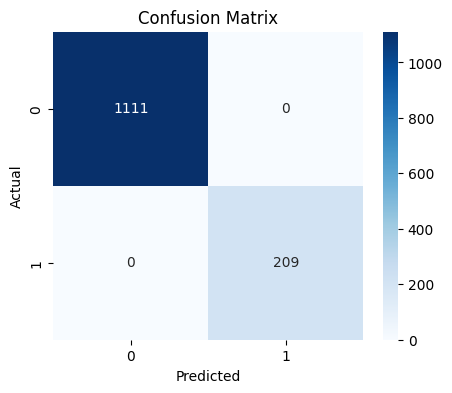

In [78]:
cm = confusion_matrix(y_test_raw, y_pred)

# plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [70]:
cv_scores_pca20 = cross_val_score(svm_model, X_train_pca20, y_train_pca20, cv=5) 

print("SVM PCA20 CV scores:", cv_scores_raw)
print("Mean CV accuracy (PCA20):", np.mean(cv_scores_pca20))
print("Standard deviation CV (PCA20):", np.std(cv_scores_pca20))

SVM PCA20 CV scores: [1. 1. 1. 1. 1.]
Mean CV accuracy (PCA20): 0.9876858035329599
Standard deviation CV (PCA20): 0.0026751361553718775


In [71]:
svm_model.fit(X_train_pca20, y_train_pca20)
y_pred_pca20 = svm_model.predict(X_test_pca20)

In [72]:
acc = accuracy_score(y_test_pca20, y_pred_pca20)
print("Accuracy:", acc)

Accuracy: 0.9878787878787879


Rezultati cross-validation pokazuju da SVM model nad originalnim (raw) podacima postiže savršenu tačnost u svim podjelama (standardna devijacija 0.0), što ukazuje na moguće preprilagođavanje modela.

Sa druge strane, primjenom PCA (20 komponenti) dolazi do blagog smanjenja tačnosti, ali i povećanja varijabilnosti rezultata između fold-ova. Ovo ukazuje na realističnije ponašanje modela i bolju sposobnost generalizacije.

SVM model nad originalnim podacima postiže savršenu tačnost u svim fold-ovima cross-validation procedure (100% u svih 5 podjela). Iako ovakav rezultat na prvi pogled djeluje idealno, on može ukazivati na preprilagođavanje modela ili na vrlo jednostavnu separabilnost podataka.

Odsustvo varijacije (standardna devijacija 0.0) dodatno potvrđuje da model daje identične rezultate na svim podskupovima, što nije tipično za realne probleme i može ukazivati na smanjenu sposobnost generalizacije.

In [73]:
#pokusavam da popravim da raw manje overfittuje
svm_raw = SVC(C=0.1, kernel='rbf', random_state=42)
cv_scores = cross_val_score(svm_raw, X_train_raw, y_train_raw, cv=5)

In [74]:
print("SVM RAW CV scores:", cv_scores)
print("Mean CV accuracy (RAW):", np.mean(cv_scores))
print("Standard deviation CV (RAW):", np.std(cv_scores))

SVM RAW CV scores: [0.98958333 0.9905303  0.98484848 0.99241706 0.98578199]
Mean CV accuracy (RAW): 0.9886322346689645
Standard deviation CV (RAW): 0.002873075758235143


In [75]:
svm_raw.fit(X_train_raw, y_train_raw)
y_pred_fixed = svm_raw.predict(X_test_raw)

In [76]:
acc = accuracy_score(y_test_raw, y_pred_fixed)
print("Accuracy:", acc)

Accuracy: 0.9962121212121212


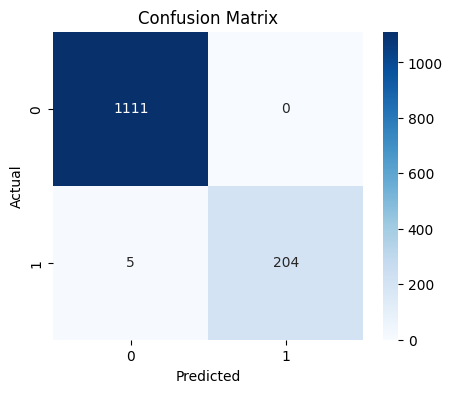

In [77]:
cm = confusion_matrix(y_test_raw, y_pred_fixed)

#plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Da bi se kontrolisao overfitting kod SVM-a na raw podacima, primijenili smo cross-validation sa podešenim regularizacionim parametrom C=0.1 i 5 foldova. Rezultati su sljedeći:

SVM RAW CV scores: [0.98958333 0.9905303  0.98484848 0.99241706 0.98578199]
Mean CV accuracy (RAW): 0.9886322346689645
Standard deviation CV (RAW): 0.002873075758235143

---------------------------------------------------------------------------------------------------------------
Random Forest treniran nad raw podacima i podacima transformisanim PCA-om pokazivao je izuzetno visoke tačnosti.
Ove vrijednosti ukazuju na ogroman overfitting, jer model gotovo savršeno predviđa podatke iz skupa za trening, ali ne reflektuje nužno sposobnost generalizacije na nove podatke.

Da bismo demonstrirali kako se overfitting može kontrolisati, primijenili smo Bagging nad Random Forest modelom sa istim parametrima (n_estimators=200, random_state=42). Bagging je agregaciona metoda koja smanjuje varijansu modela kroz učenje više podmodela nad slučajno odabranim podskupovima podataka.

In [52]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [53]:
rf_base = RandomForestClassifier(n_estimators=200, random_state=42)

In [54]:
bagging_rf = BaggingClassifier(
    estimator = rf_base,
    n_estimators=10,        #broj bagging modela
    random_state=42,
    n_jobs=-1
)

In [57]:
cv_scores_rf = cross_val_score(bagging_rf, X_raw, y, cv=5) #nad cijelim Xraw i y

In [58]:
print("Bagged Random Forest CV scores:", cv_scores_rf)
print("Mean CV accuracy (Bagged RF):", np.mean(cv_scores_rf))
print("Standard deviation CV (Bagged RF):", np.std(cv_scores_rf))

Bagged Random Forest CV scores: [0.89090909 1.         0.86818182 1.         1.        ]
Mean CV accuracy (Bagged RF): 0.9518181818181818
Standard deviation CV (Bagged RF): 0.05944648263371571


Originalni Random Forest nad RAW podacima pokazuje tačnost 1.0, što ukazuje na veliki overfitting.
Da bi se smanjio overfitting, primijenila sam bagging metodu:

Osnovni model: RandomForestClassifier(n_estimators=200, random_state=42)
Bagging: BaggingClassifier(estimator=rf_base, n_estimators=10, random_state=42, n_jobs=-1)
Evaluacija: 5-fold cross-validation

Rezultati:

Bagged Random Forest CV scores: [0.891, 1.0, 0.868, 1.0, 1.0]
Mean CV accuracy: 0.952
Standard deviation: 0.059

Zaključak: Bagging je značajno smanjio overfitting i poboljšao stabilnost modela.